# PricePoint — 07 · Gradient Boosting

**What it is:** builds small decision trees **one after another**. The first tree makes a rough guess. Each new tree is trained to fix the **mistakes the previous trees left behind**. The final price is the first guess plus all the small corrections added up.

**Not the same as Random Forest:** a Random Forest grows its trees independently and averages them. Gradient Boosting grows them in a chain, each one learning from the last.

**Settings:** the same as the final model in `src/train_and_export.py` (the one the website uses), so these scores describe the model that is actually deployed. `learning_rate` is how big each correction step is — small steps are safer.

In [1]:
import json

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed, so charts will be skipped. To see them: pip install matplotlib")

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [14]:


for base in (Path(".."), Path("."), Path("ml")):
    if (base / "data" / "laptop_price_clean.csv").exists():
        DATA_DIR = base / "data"
        MODEL_DIR = base / "models"
        break
else:
    raise FileNotFoundError(
        "Cannot find data/laptop_price_clean.csv - open this notebook from the ml folder or the ml/notebooks folder."
    )

MODEL_DIR.mkdir(exist_ok=True)

In [15]:


clean = pd.read_csv(DATA_DIR / "laptop_price_clean.csv")


clean["touchscreen"] = clean["touchscreen"].astype(int)
clean["ips"] = clean["ips"].astype(int)


categorical_columns = ["brand", "type", "cpu_brand", "storage_type", "gpu_brand", "os"]
numeric_columns = [
    "inches",
    "touchscreen",
    "ips",
    "resolution_pixels",
    "cpu_speed_ghz",
    "ram_gb",
    "storage_gb",
    "weight_kg",
]

X = clean[categorical_columns + numeric_columns]
y = clean["price_bdt"]

print("rows:", len(X))
print("features:", X.shape[1])

rows: 1303
features: 14


## Split into training and testing

In [16]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("training rows:", len(X_train))
print("testing rows :", len(X_test))

training rows: 1042
testing rows : 261


## Build the pipeline

Two jobs in one object:
1. turn the text columns into numbers (one-hot encoding)
2. fit the model on those numbers

Trees do not care about scale, so no scaler is needed.

In [17]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "category",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_columns,
        ),
        ("number", "passthrough", numeric_columns),
    ]
)

In [18]:

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=120,     
        max_depth=4,          
        learning_rate=0.08,   
        subsample=0.85,       
        random_state=42,
    )),
])

In [19]:
pipeline.fit(X_train, y_train)
print("model trained")

model trained


## Score it

Three numbers, same meaning everywhere in this project:

- **MAE** — average miss in taka ("on average we are off by X BDT")
- **RMSE** — like MAE, but big mistakes are punished harder
- **R²** — how much of the price spread the model explains (1.0 = perfect, 0 = useless)

We score twice: on the held-out **test set**, and with **5-fold cross-validation** (more reliable — the data is shuffled and scored 5 different ways).

In [20]:


y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_train = pipeline.score(X_train, y_train)

print("R² on training data :", round(r2_train, 3))
print("R² on test data     :", round(r2, 3))
print("MAE                 :", round(mae), "BDT")
print("RMSE                :", round(rmse), "BDT")

R² on training data : 0.939
R² on test data     : 0.822
MAE                 : 21398 BDT
RMSE                : 37564 BDT


## Cross-validation

Shuffle the data, train 5 times on different slices, average the scores.

In [ ]:


cv_mae = -cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")
cv_rmse = -cross_val_score(pipeline, X, y, cv=5, scoring="neg_root_mean_squared_error")
cv_r2 = cross_val_score(pipeline, X, y, cv=5, scoring="r2")

print("CV MAE :", round(cv_mae.mean()), "±", round(cv_mae.std()))
print("CV RMSE:", round(cv_rmse.mean()), "±", round(cv_rmse.std()))
print("CV R²  :", round(cv_r2.mean(), 3), "±", round(cv_r2.std(), 3))

CV MAE : 24604 ± 1308
CV RMSE: 36883 ± 3614
CV R²  : 0.817 ± 0.032


### Watch it improve as trees are added

After 1 tree the guess is rough. Every extra tree fixes some of the remaining error, so the error drops. This chart is the "each tree fixes the last one's mistakes" idea in one picture.

after   1 trees: MAE =  60534 BDT
after  10 trees: MAE =  40403 BDT
after  30 trees: MAE =  26313 BDT
after  60 trees: MAE =  23186 BDT
after 120 trees: MAE =  21398 BDT


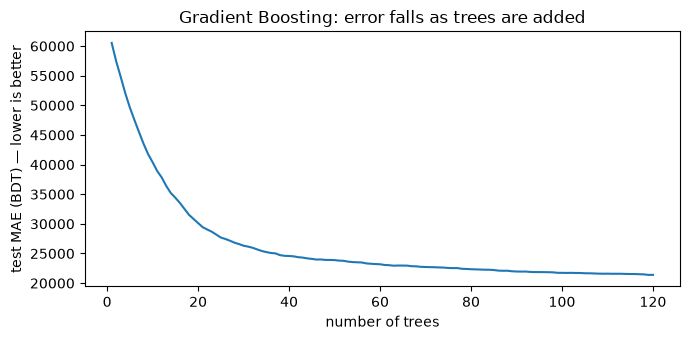

In [21]:


X_test_ready = pipeline.named_steps["preprocessing"].transform(X_test)
booster = pipeline.named_steps["model"]

mae_by_trees = [
    mean_absolute_error(y_test, y_stage)
    for y_stage in booster.staged_predict(X_test_ready)
]

for trees in (1, 10, 30, 60, 120):
    print(f"after {trees:>3} trees: MAE = {round(mae_by_trees[trees - 1]):>6} BDT")

if plt is not None:
    plt.figure(figsize=(7, 3.5))
    plt.plot(range(1, len(mae_by_trees) + 1), mae_by_trees)
    plt.xlabel("number of trees")
    plt.ylabel("test MAE (BDT) — lower is better")
    plt.title("Gradient Boosting: error falls as trees are added")
    plt.tight_layout()
    plt.show()

### Which features did it rely on most?

In [23]:


feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
importances = pd.Series(
    pipeline.named_steps["model"].feature_importances_, index=feature_names
)

print(importances.sort_values(ascending=False).head(10).to_string())

number__ram_gb                  0.480234
number__weight_kg               0.109898
category__type_Notebook         0.069767
category__cpu_brand_Intel i7    0.056534
number__resolution_pixels       0.050531
number__cpu_speed_ghz           0.050288
category__type_Workstation      0.030753
number__inches                  0.027735
category__cpu_brand_Intel i5    0.019622
category__brand_Razer           0.018088


## Try it on 3 real laptops

In [ ]:

sample = X_test.head(3)
sample_predicted = pipeline.predict(sample)

for position in range(3):
    real_price = y_test.iloc[position]
    predicted_price = round(sample_predicted[position])
    print("real:", real_price, "BDT    predicted:", predicted_price, "BDT")

real: 209000 BDT    predicted: 161704 BDT
real: 143625 BDT    predicted: 160822 BDT
real: 62375 BDT    predicted: 60276 BDT


## Save the scores

Notebook `08_compare_models.ipynb` reads these files.

In [25]:

metrics = {
    "model": "Gradient Boosting",
    "test_mae": round(mae, 2),
    "test_rmse": round(rmse, 2),
    "test_r2": round(r2, 4),
    "cv_mae": round(cv_mae.mean(), 2),
    "cv_rmse": round(cv_rmse.mean(), 2),
    "cv_r2": round(cv_r2.mean(), 4),
}

metrics_path = MODEL_DIR / "metrics_gradient_boosting.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("saved:", metrics_path)

saved: ..\models\metrics_gradient_boosting.json


**Next notebook:** `08_compare_models.ipynb` — puts all six side by side.